# Uncertainty quantification for differential cross sections using KDUQ

KDUQ is an uncertainty quantified global optical potential (see [Pruitt et al., 2023](https://journals.aps.org/prc/abstract/10.1103/PhysRevC.107.014602)).

It is one of the potentials built into `jitr`. We will see how to use it for propagating uncertainties in this demo.

In [1]:
# import stuff for nice plotting
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

import jitr

In [2]:
from jitr.optical_potentials import kduq

In [3]:
#  elastic reaction
target = (54, 26)
proton = (1, 1)
neutron = (1, 0)
projectile = proton

reaction = jitr.reactions.ElasticReaction(
    target=target,
    projectile=projectile,
)

# energy
Elab = 35
kinematics = reaction.kinematics(Elab)

# for plotting differential xs
angles = np.linspace(0.1, np.pi, 180)

# Lagrange Mesh
core_solver = jitr.rmatrix.Solver(40)

# set up our solver to calculate differential cross sections

In [4]:
# get kinematics and parameters for this experiment

a = jitr.utils.interaction_range(target[0]) * kinematics.k + np.pi * 2
N = jitr.utils.suggested_basis_size(a)
assert N < core_solver.kernel.quadrature.nbasis
channel_radius_fm = a / kinematics.k

# build solver
solver = jitr.xs.elastic.DifferentialWorkspace.build_from_system(
    reaction=reaction,
    kinematics=kinematics,
    channel_radius_fm=channel_radius_fm,
    solver=core_solver,
    lmax=50,
    angles=angles,
)

# grab kduq posterior samples 

In [5]:
help(kduq.get_samples)

Help on function get_samples in module jitr.optical_potentials.kduq:

get_samples(projectile: tuple, posterior: str = 'federal')
    Get the posterior samples for the given projectile (neutron or
    proton) from the KDUQ Federal or Democratic posteriors.

    See [Pruitt, et al., 2023]
    (https://journals.aps.org/prc/pdf/10.1103/PhysRevC.107.014602) for
    details on the KDUQ posteriors.

    Parameters:
    ----------
    projectile : tuple
        A tuple representing the projectile, with format (Ap, Zp), where
        Ap is the mass number and Zp is the atomic number. Must be
        either (1, 0) for neutron or (1, 1) for proton.
    posterior : str
        Which KDUQ posterior to return samples from. Must be either
        "federal" or "democratic". Defaults to "federal".

    Returns:
    -------
    np.ndarray
        An array of shape (NUM_POSTERIOR_SAMPLES, num_params) containing
        the posterior samples for the given projectile, where num_params
        is the number

In [6]:
kduq_samples = kduq.get_samples(projectile)

## Set up the potential

Let's take a look at the functionality built into jitr:

In [8]:
omp = kduq.KDUQ(projectile)
help(omp)

Help on KDUQ in module jitr.optical_potentials.kduq object:

class KDUQ(jitr.optical_potentials.omp.SingleChannelOpticalModel)
 |  KDUQ(projectile: tuple)
 |
 |  Koning-Delaroche Uncertainty Quantification (KDUQ) optical
 |  potential model.
 |
 |  Method resolution order:
 |      KDUQ
 |      jitr.optical_potentials.omp.SingleChannelOpticalModel
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, projectile: tuple)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  params_by_term(self, reaction: Reaction, kinematics: ChannelKinematics, *params) -> tuple
 |      Calculate the central, spin-orbit, and Coulomb parameters for
 |      the Koning-Delaroche potential based on the provided parameters
 |      and the reaction and kinematics.
 |
 |      Parameters:
 |      ----------
 |      reaction : Reaction
 |          The reaction for which to calculate the parameters.
 |      kinematics : ChannelKinematics
 |          The kinematics of the

In [9]:
help(jitr.optical_potentials.kduq.central)

Help on function central in module jitr.optical_potentials.kduq:

central(r, Vv, Rv, av, Wv, Rwv, awv, Wd, Rd, ad) -> complex
    Koning-Delaroche central terms at a given energy, Eq. (7) in Koning and Delaroche (2003).

    Parameters:
    ----------
    r : float or np.ndarray
        The radius at which to evaluate the potential.
    Vv : float
        The real central depth.
    Rv : float
        The real central radius parameter.
    av : float
        The real central diffuseness parameter.
    Wv : float
        The imaginary volume depth.
    Rwv : float
        The imaginary volume radius parameter.
    awv : float
        The imaginary volume diffuseness parameter.
    Wd : float
        The imaginary surface depth.
    Rd : float
        The imaginary surface radius parameter.
    ad : float
        The imaginary surface diffuseness parameter.



In [10]:
help(jitr.optical_potentials.kduq.spin_orbit)

Help on function spin_orbit in module jitr.optical_potentials.kduq:

spin_orbit(r, Vso, Rso, aso, Wso, Rwso, awso) -> complex
    Koning-Delaroche spin-orbit terms at a given energy, Eq. (7) in Koning and Delaroche (2003).

    Parameters:
    ----------
    r : float or np.ndarray
        The radius at which to evaluate the potential.
    Vso : float
        The real spin-orbit depth.
    Rso : float
        The real spin-orbit radius parameter.
    aso : float
        The real spin-orbit diffuseness parameter.
    Wso : float
        The imaginary spin-orbit depth.
    Rwso : float
        The imaginary spin-orbit radius parameter.
    awso : float
        The imaginary spin-orbit diffuseness parameter.



In [11]:
help(jitr.optical_potentials.potential_forms.coulomb_charged_sphere)

Help on function coulomb_charged_sphere in module jitr.optical_potentials.potential_forms:

coulomb_charged_sphere(r, zz, r_c)



# run calculation

This should demonstrate how the `KDUQ` class (`omp`) is built to interface with `solver`, which is an instance of `jitr.xs.elastic.DifferentialWorkspace`. This is how calculations are done in jitr.

In [12]:
kduq_xs = np.zeros((len(angles), kduq.NUM_POSTERIOR_SAMPLES))
rgrid = solver.radial_grid()

for j, sample in enumerate(tqdm(kduq_samples)):
    central_term, spin_orbit_term, coulomb_term = omp(
        rgrid, reaction, kinematics, *sample
    )
    xs = solver.xs(central_term, spin_orbit_term, coulomb_term)
    kduq_xs[:, j] = xs.dsdo / solver.rutherford

 92%|█████████▏| 384/416 [00:13<00:00, 199.16it/s]/mnt/ffs24/home/beyerkyl/jitr/src/jitr/optical_potentials/kduq.py:481: RuntimeWarning: overflow encountered in exp
  d2 = d2_0 + d2_A / (1 + np.exp((A - d2_A3) / d2_A2))
100%|██████████| 416/416 [00:13<00:00, 30.67it/s] 


# calculate CIs and plot

In [13]:
kduq_pred_post = np.percentile(kduq_xs, [16, 84], axis=1)

Text(0, 0.5, '$\\frac{d \\sigma}{d\\Omega} / \\frac{d \\sigma_{R}}{d\\Omega} $')

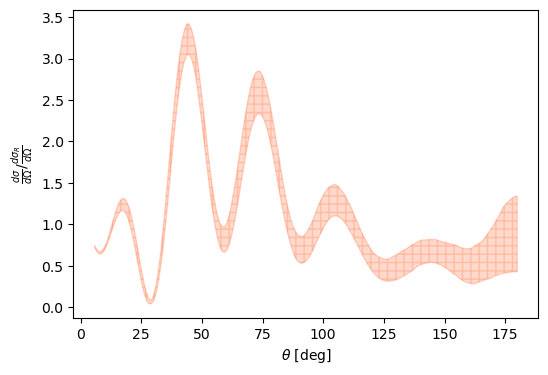

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
ax.fill_between(
    angles * 180 / np.pi,
    kduq_pred_post[0],  # / solver.rutherford,
    kduq_pred_post[1],  # / solver.rutherford,
    color="#ff4500",
    hatch="|-|-",
    alpha=0.2,
)
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$\frac{d \sigma}{d\Omega} / \frac{d \sigma_{R}}{d\Omega} $")

In [15]:
# NBVAL_CHECK_OUTPUT
print(f"{kduq_pred_post[1][9]:1.6f}")

1.163423


In fact, `KDUQ` is just one definition of a global optical potential. `jitr` also has others built in:

In [16]:
help(jitr.optical_potentials.wlh.WLH)

Help on class WLH in module jitr.optical_potentials.wlh:

class WLH(jitr.optical_potentials.omp.SingleChannelOpticalModel)
 |  WLH(projectile: tuple)
 |
 |  The Whitehead-Lim-Holt global optical potential for nucleon-nucleus
 |  scattering.
 |
 |  Method resolution order:
 |      WLH
 |      jitr.optical_potentials.omp.SingleChannelOpticalModel
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self, projectile: tuple)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  params_by_term(self, reaction: Reaction, kinematics: ChannelKinematics, *params) -> tuple
 |      Calculate the arguments for the central, spin_orbit, and
 |      coulomb_charged_sphere functions corresponding to the WLH potential
 |      for a given projectile, target, lab energy, and the WLH parameters.
 |
 |
 |      Parameters:
 |      ----------
 |      reaction : Reaction
 |          The reaction for which to calculate the parameters.
 |      kinematics : ChannelKinematic

In [17]:
help(jitr.optical_potentials.chuq.CHUQ)

Help on class CHUQ in module jitr.optical_potentials.chuq:

class CHUQ(jitr.optical_potentials.omp.SingleChannelOpticalModel)
 |  Chapel-Hill Uncertainty Quantification (CHUQ) optical
 |  potential model.
 |
 |  Note that CH89 is Lane consistent, so the same parameters can be
 |  used for both neutron and proton projectiles.
 |
 |  Method resolution order:
 |      CHUQ
 |      jitr.optical_potentials.omp.SingleChannelOpticalModel
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(self)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  params_by_term(self, reaction: Reaction, kinematics: ChannelKinematics, *params) -> tuple
 |      Calculate the central, spin-orbit, and Coulomb parameters for
 |      the Chapel-Hill '89 potential based on the provided parameters
 |      and the reaction and kinematics.
 |
 |      Parameters:
 |      ----------
 |      reaction : Reaction
 |          The reaction for which to calculate the parameters.
 |     

In fact, these are all derived from `jitr.optical_potentials.SingleChannelOpticalModel`, which sets the interface between the model for the effective interaction and the solver. You can come up with your own optical model and derive your own class from `jitr.optical_potentials.SingleChannelOpticalModel` to plug it into jitr!

In [18]:
help(jitr.optical_potentials.SingleChannelOpticalModel)

Help on class SingleChannelOpticalModel in module jitr.optical_potentials.omp:

class SingleChannelOpticalModel(builtins.object)
 |  SingleChannelOpticalModel(
 |      params: list[str],
 |      interaction_central: Callable[[float, tuple], complex],
 |      interaction_spin_orbit: Callable[[float, tuple], complex],
 |      interaction_coulomb: Callable[[float, tuple], complex] = None
 |  )
 |
 |  A simple optical model base class that uses a central and spin-orbit
 |  interaction.
 |
 |  For use with jitr.xs.elastic.DifferentialWorkspace, which requires
 |  as input functions U(r;params_{central}) and U_{so}(r;params_{so})
 |  for the central and spin-orbit interactions, respectively. These are
 |  provided as callables that take a radius and a tuple of parameters
 |  and return a complex potential.
 |
 |  In general, the parameters for the central and spin-orbit
 |  interactions may depend on the reaction and kinematics, so the class
 |  includes a method central_and_spin_orbit_param